# 14. Stomach mct mc donor

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize

from ALLCools.clustering import *
from ALLCools.plot import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.mcds import MCDS

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [ ]:
indir = f'{ENTEX_ROOT}/'
mct_dir = f'{indir}mCT/'
m3c_dir = f'{indir}mcds/'
outdir = f'{indir}analysis/stomach_mct/'


In [ ]:
var_dim = 'chrom5k'
chrom_to_remove = ['chrX', 'chrY', 'chrM', 'chrL']
black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'


In [ ]:
meta = anndata.read_h5ad(f'{mct_dir}entex_1_rna.h5ad', 'r').obs
selc = meta.index[(meta['UniqueAlignFinalReads']>500000) & (meta['mCCCFrac']<0.1)]
print(len(selc))


In [ ]:
mcds = MCDS.open(f'{mct_dir}entex_1.mcds', use_obs=selc, var_dim=var_dim)
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds

42669 chrom5k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


<xarray.MCDS> Size: 7GB
Dimensions:                    (cell: 5768, chrom5k: 575010)
Coordinates:
  * cell                       (cell) <U21 485kB 'SM_IOBHV_P2-6-E5-A23' ... '...
  * chrom5k                    (chrom5k) <U11 25MB 'chr1_0' ... 'chr9_27678'
    chrom5k_chrom              (chrom5k) <U5 12MB 'chr1' 'chr1' ... 'chr9'
    chrom5k_end                (chrom5k) int64 5MB ...
    chrom5k_start              (chrom5k) int64 5MB ...
Data variables:
    chrom5k_da_CGN-hypo-score  (cell, chrom5k) float16 7GB dask.array<chunksize=(7, 77210), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom5k

In [ ]:
mcad = mcds.get_score_adata(mc_type='CGN', quant_type='hypo')
binarize_matrix(mcad, cutoff=0.95)
filter_regions(mcad, n_cell=5)
remove_black_list_region(mcad, black_list_path=black_list_path)
mcad.write_h5ad(f'{outdir}5kCG.h5ad')


Loading chunk 0-5768/5768


In [ ]:
model = LSI(scale_factor=10000,
            n_components=50,
            algorithm='arpack',
            random_state=0)


In [ ]:
raw_key = '5kCG_lsi'
obsm_key = 'X_lsi'
model.fit_transform(mcad, obsm_name='5kCG_lsi')
npc = significant_pc_test(mcad, p_cutoff=0.1, obsm=raw_key, update=False)


17 components passed P cutoff of 0.1.


In [ ]:
mcad.obs['Donor'] = mcad.obs.index.str.split('_').str[1]
mcad.obs['Donor'].value_counts()

Donor
JFINP    2895
IOBHV    2873
Name: count, dtype: int64

In [ ]:
mcad.obsm[obsm_key] = normalize(mcad.obsm[raw_key][:, :npc], axis=1)
tsne(mcad, obsm=obsm_key, metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
mcad.obsm[f'5kCG_u{npc}_tsne'] = mcad.obsm['X_tsne'].copy()


In [ ]:
sce.pp.harmony_integrate(mcad, 'Donor', basis=obsm_key, adjusted_basis=f'{obsm_key}_harmony', max_iter_harmony=30, random_state=0)


2025-08-26 16:46:05,475 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-26 16:46:06,105 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-26 16:46:06,132 - harmonypy - INFO - Iteration 1 of 30
2025-08-26 16:46:06,753 - harmonypy - INFO - Iteration 2 of 30
2025-08-26 16:46:07,358 - harmonypy - INFO - Iteration 3 of 30
2025-08-26 16:46:07,943 - harmonypy - INFO - Iteration 4 of 30
2025-08-26 16:46:08,447 - harmonypy - INFO - Iteration 5 of 30
2025-08-26 16:46:08,695 - harmonypy - INFO - Iteration 6 of 30
2025-08-26 16:46:08,858 - harmonypy - INFO - Iteration 7 of 30
2025-08-26 16:46:09,022 - harmonypy - INFO - Iteration 8 of 30
2025-08-26 16:46:09,183 - harmonypy - INFO - Iteration 9 of 30
2025-08-26 16:46:09,347 - harmonypy - INFO - Converged after 9 iterations


In [ ]:
tsne(mcad, obsm=f'{obsm_key}_harmony', metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
mcad.obsm[f'5kCG_u{npc}hm_tsne'] = mcad.obsm['X_tsne'].copy()


In [ ]:
sc.pp.neighbors(mcad, use_rep=f'{obsm_key}_harmony', n_neighbors=25)
sc.tl.leiden(mcad, resolution=1.0, key_added=f'5kCG_u{npc}hm_leiden')

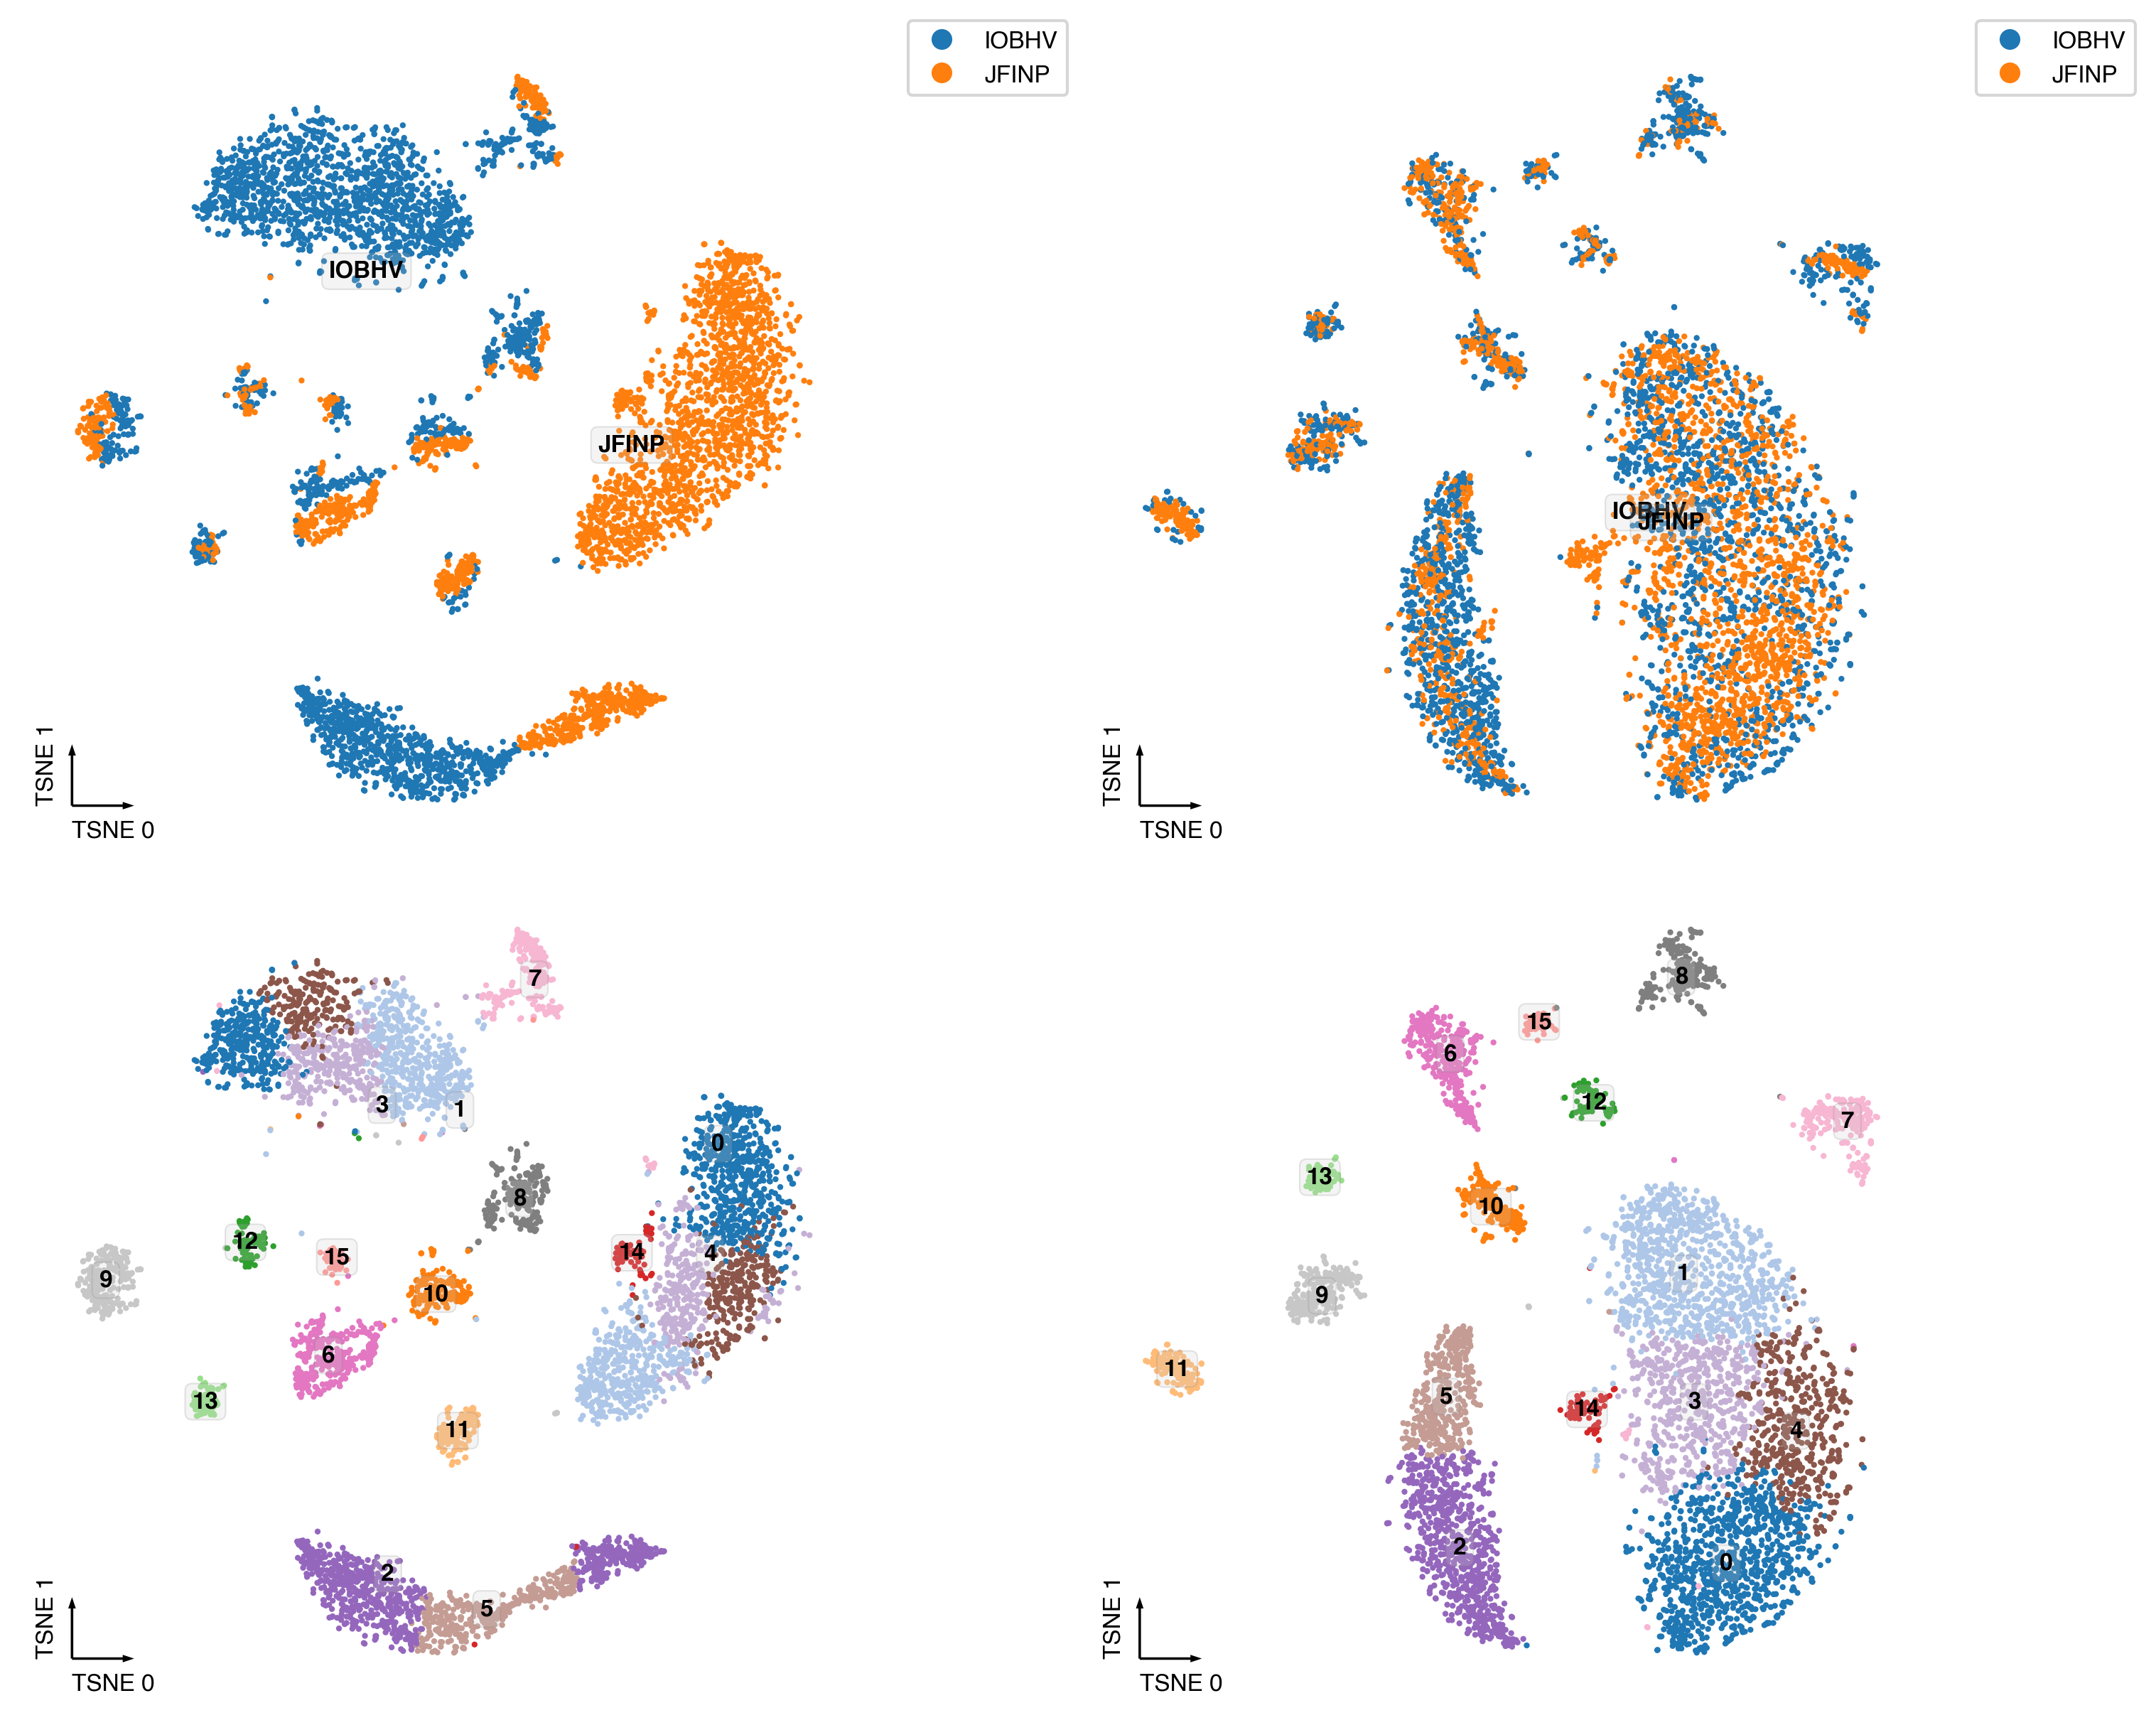

In [ ]:
ds = 4
coord_base = 'tsne'

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300, constrained_layout=True)

for i,mode in enumerate(['', 'hm']):
    mcad.obsm[f'X_{coord_base}'] = mcad.obsm[f'5kCG_u{npc}{mode}_tsne'].copy()
    dump_embedding(mcad, coord_base)
    tmp = mcad.obs.copy()
    ax = axes[0,i]
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue='Donor',
                            text_anno='Donor',
                            labelsize=8,
                            s=ds,
                            palette='tab10',
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1},
                            show_legend=True
                            )
    ax = axes[1,i]
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=f'5kCG_u{npc}hm_leiden',
                            text_anno=f'5kCG_u{npc}hm_leiden',
                            labelsize=8,
                            s=ds,
                            palette='tab20',
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1},
                            # show_legend=True
                            )


In [ ]:
mcad = anndata.AnnData(obs=mcad.obs, obsm=mcad.obsm, obsp=mcad.obsp)
mcad.write_h5ad(f'{outdir}5kCG_embed.h5ad')


In [ ]:
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', header=0, index_col=0)
meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']] = meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']].astype(str)
meta = meta.loc[meta['Tissue']=='ST']
meta

,cluster,subtype,majortype,FinalmCReads,mCHFrac,mCGFrac,CisLongContact,Cis/Trans,Short/Long,Donor,...,L2_5kCG_tsne_0,L2_5kCG_tsne_1,L2_100k3C_tsne_0,L2_100k3C_tsne_1,Tissue_joint_tsne_0,Tissue_joint_tsne_1,Tissue_5kCG_tsne_0,Tissue_5kCG_tsne_1,Tissue_100k3C_tsne_0,Tissue_100k3C_tsne_1
cell,,,,,,,,,,,,,,,,,,,,,
ST_IOBHV_Plate1-6-K11-A12,c21-c1,c21-b0,c21,2080168,0.008983,0.739310,243750,1.311154,-0.184424,PT-1LGRB,...,23.489016,1.438899,-8.640621,16.523927,28.597974,1.343581,9.880017,-35.979834,11.273734,13.907289
ST_IOBHV_Plate4-1-A13-A14,c21-c1,c21-b0,c21,1383986,0.007296,0.742840,166457,1.255256,-0.346443,PT-1LGRB,...,24.853207,-1.850522,-2.400435,16.672730,28.519392,1.377324,9.729270,-35.934055,11.018332,13.248825
ST_IOBHV_Plate5-5-G13-J22,c21-c1,c21-b0,c21,2723877,0.008452,0.728836,315038,1.197235,-0.143494,PT-1LGRB,...,23.414455,-4.564477,-5.382414,10.484456,28.769589,1.248974,9.976342,-36.121078,11.995398,15.380118
ST_JF1O3_Plate2-2-E3-L16,c21-c1,c21-b0,c21,2122812,0.009482,0.728182,260333,1.131317,-0.434568,PT-1LVAN,...,25.285218,-0.668342,-1.445580,10.581781,28.643290,1.346309,9.977080,-35.641330,10.202139,14.165954
ST_JF1O3_Plate3-1-G3-C14,c21-c1,c21-b0,c21,3183117,0.009695,0.722669,420257,1.088292,-0.392230,PT-1LVAN,...,24.929229,-1.814531,-8.540182,19.785506,28.625879,1.214352,10.053244,-35.974100,11.048261,14.303424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ST_JF1O3_Plate8-5-E5-M9,c7-c6,c7-b0,c7,2120620,0.012214,0.567616,196580,0.703005,-0.748786,PT-1LVAN,...,-29.493173,18.732197,-19.014733,13.984659,25.194591,-19.387645,30.740181,5.969420,1.710476,62.648021
ST_JF1O3_Plate8-6-E5-C24,c7-c1,c7-b0,c7,1044923,0.010183,0.651940,77613,0.472737,-0.975981,PT-1LVAN,...,-9.999941,-9.749384,-3.000328,-1.099103,21.899310,-22.573029,32.609283,1.136371,-2.176680,61.461044
ST_JF1O3_Plate8-6-E5-D12,c7-c5,c7-b2,c7,1228376,0.011243,0.675089,95475,0.520524,-1.371023,PT-1LVAN,...,-28.023172,-1.542242,-2.508431,20.238084,23.344481,-24.349918,6.080356,5.866991,-1.940362,62.801380


In [ ]:
mcds = MCDS.open(f'{m3c_dir}*ST*.mcds', use_obs=meta.index, var_dim=var_dim)
mcds = mcds.remove_chromosome(exclude_chromosome=chrom_to_remove, var_dim=var_dim)
mcds

42659 chrom5k features in ['chrX', 'chrY', 'chrM', 'chrL'] removed.


<xarray.MCDS> Size: 7GB
Dimensions:                    (cell: 5982, chrom5k: 575010)
Coordinates:
  * cell                       (cell) <U25 598kB 'ST_IOBHV_Plate1-1-K11-A1' ....
  * chrom5k                    (chrom5k) <U11 25MB 'chr1_0' ... 'chr9_27678'
    chrom5k_chrom              (chrom5k) <U5 12MB 'chr1' 'chr1' ... 'chr9'
    chrom5k_end                (chrom5k) int64 5MB ...
    chrom5k_start              (chrom5k) int64 5MB ...
Data variables:
    chrom5k_da_CGN-hypo-score  (cell, chrom5k) float16 7GB dask.array<chunksize=(7, 77209), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom5k

In [ ]:
mcad = mcds.get_score_adata(mc_type='CGN', quant_type='hypo')
binarize_matrix(mcad, cutoff=0.95)
filter_regions(mcad, n_cell=5)
remove_black_list_region(mcad, black_list_path=black_list_path)
mcad.write_h5ad(f'{indir}clustering/tissue/L1/ST/5kCG.h5ad')


Loading chunk 0-5982/5982


In [4]:
adata1 = anndata.read_h5ad(f'{outdir}5kCG.h5ad')
adata2 = anndata.read_h5ad(f'{indir}clustering/tissue/L1/ST/5kCG.h5ad')
print(adata1.shape, adata2.shape)


(5768, 503967) (5982, 499832)


In [5]:
meta = anndata.read_h5ad(f'{outdir}5kCG_embed.h5ad').obs
adata1.obs = meta.loc[adata1.obs.index].copy()
adata1.obs['Donor'] = adata1.obs['Donor'].replace({'JFINP': 'PT-1LVAN', 'IOBHV': 'PT-1LGRB'})
adata1.obs['Donor'].value_counts()

/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Donor
PT-1LVAN    2895
PT-1LGRB    2873
Name: count, dtype: int64

In [6]:
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', header=0, index_col=0)
meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']] = meta[['Donor', 'Tissue', 'cluster', 'subtype', 'majortype']].astype(str)
meta = meta.loc[meta['Tissue']=='ST']
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_color = L1_meta['color'].to_dict()
L1_annot = L1_meta['L1_abbr'].to_dict()
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0)
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()
adata2.obs = meta.loc[adata2.obs.index].copy()
adata2.obs['L2_annot'] = adata2.obs['subtype'].map(L2_annot).astype(str)
adata2.obs['L1_annot'] = adata2.obs['majortype'].map(L1_annot).astype(str)


In [35]:
count = adata2.obs['L2_annot'].value_counts()
selct = np.sort(count.index[:20])
l2_palette = {xx:yy for xx,yy in zip(selct, sns.color_palette('tab20'))}
l2_palette[selct[14]] = (0.0, 0.0, 0.0)
l2_palette[selct[15]] = (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)


In [34]:
count = adata1.obs['5kCG_u17hm_leiden'].value_counts()
leiden_palette = {xx:yy for xx,yy in zip(count.index, sns.color_palette('tab20', count.shape[0]))}


In [29]:
for donor in adata1.obs['Donor'].unique():
    tmp1 = adata1[adata1.obs['Donor']==donor].copy()
    tmp2 = adata2[adata2.obs['Donor']==donor].copy()
    tmp1.var['n_cells'] = adata1.X.sum(axis=0).A1
    tmp2.var['n_cells'] = adata2.X.sum(axis=0).A1
    selb = tmp1.var.index[tmp1.var['n_cells']>5].intersection(tmp2.var.index[tmp2.var['n_cells']>5])
    tmp1 = tmp1[:, selb].copy()
    tmp2 = tmp2[:, selb].copy()
    model = LSI(scale_factor=10000,
                n_components=50,
                algorithm='arpack',
                random_state=0)

    model.fit_transform(tmp1, obsm_name='lsi_all')
    model.transform(tmp2, obsm_name='lsi_all')
    npc = significant_pc_test(tmp1, p_cutoff=0.05, obsm='lsi_all', update=False)
    tmp1.obsm['X_lsi'] = normalize(tmp1.obsm['lsi_all'][:, :npc], axis=1)
    tmp2.obsm['X_lsi'] = normalize(tmp2.obsm['lsi_all'][:, :npc], axis=1)
    tmp1.obs['study'] = 'mCT'
    tmp2.obs['study'] = 'm3C'
    adata_list = [tmp1, tmp2]
    integrator = SeuratIntegration()
    integrator.find_anchor(adata_list,
                            k_local=None,
                            key_local='X_lsi',
                            k_anchor=5,
                            key_anchor='X',
                            dim_red='lsi-cca',
                            max_cc_cells=50000,
                            k_score=30,
                            k_filter=None,
                            scale_list=[False, False],
                            alignments=[[[0],[1]]],
                            n_components=npc,
                            n_features=200)
    # thres = np.percentile(anchor['dist_pc'], 60)
    # integrator.anchor[(0,1)] = anchor.loc[anchor['dist_pc']<thres, ['x1','x2','score']].copy()
    corrected = integrator.integrate(key_correct='X_lsi',
                                    row_normalize=True,
                                    n_components=npc,
                                    k_weight=100,
                                    alignments=[[[0],[1]]],
                                    sd=1)
    adata_merge = anndata.AnnData(obs=pd.concat([tmp1.obs, tmp2.obs], axis=0))
    adata_merge.obsm['lsi_all'] = np.concatenate([tmp1.obsm['lsi_all'], tmp2.obsm['lsi_all']], axis=0)
    corrected = pd.DataFrame(normalize(np.concatenate(corrected, axis=0), axis=1), 
                            index=np.concatenate([xx.obs.index for xx in adata_list]))

    adata_merge.obsm[f'5kCG_u{npc}_seuratcc{npc}'] = corrected.loc[adata_merge.obs.index].values

    tsne(adata_merge, obsm=f'5kCG_u{npc}_seuratcc{npc}', metric='euclidean', exaggeration=-1, perplexity=50, n_jobs=-1)
    adata_merge.obsm[f'5kCG_u{npc}_seuratcc{npc}_tsne'] = adata_merge.obsm['X_tsne'].copy()
    adata_merge.write_h5ad(f'{outdir}ST_mCT_m3C_{donor}_merged.h5ad')



17 components passed P cutoff of 0.05.
Find anchors across datasets.
Get scale1 and scale2 from scale_list
dataset 0 scale: False
dataset 1 scale: False
Run LSI-CCA
Find Anchors using k=30
Score Anchors
Identified 7210 anchors between datasets 0 and 1.
Merge datasets
[[0], [1]]
Initialize
Find nearest anchors. k_weight:  100
Normalize graph
Transform data
21 components passed P cutoff of 0.05.
Find anchors across datasets.
Get scale1 and scale2 from scale_list
dataset 0 scale: False
dataset 1 scale: False
Run LSI-CCA
Find Anchors using k=30
Score Anchors
Identified 6482 anchors between datasets 0 and 1.
Merge datasets
[[0], [1]]
Initialize
Find nearest anchors. k_weight:  100
Normalize graph
Transform data


In [40]:
adata1.obs['Donor'].unique()

['PT-1LGRB', 'PT-1LVAN']
Categories (2, object): ['PT-1LGRB', 'PT-1LVAN']

/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/zhoujt/.conda/envs/analysis/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


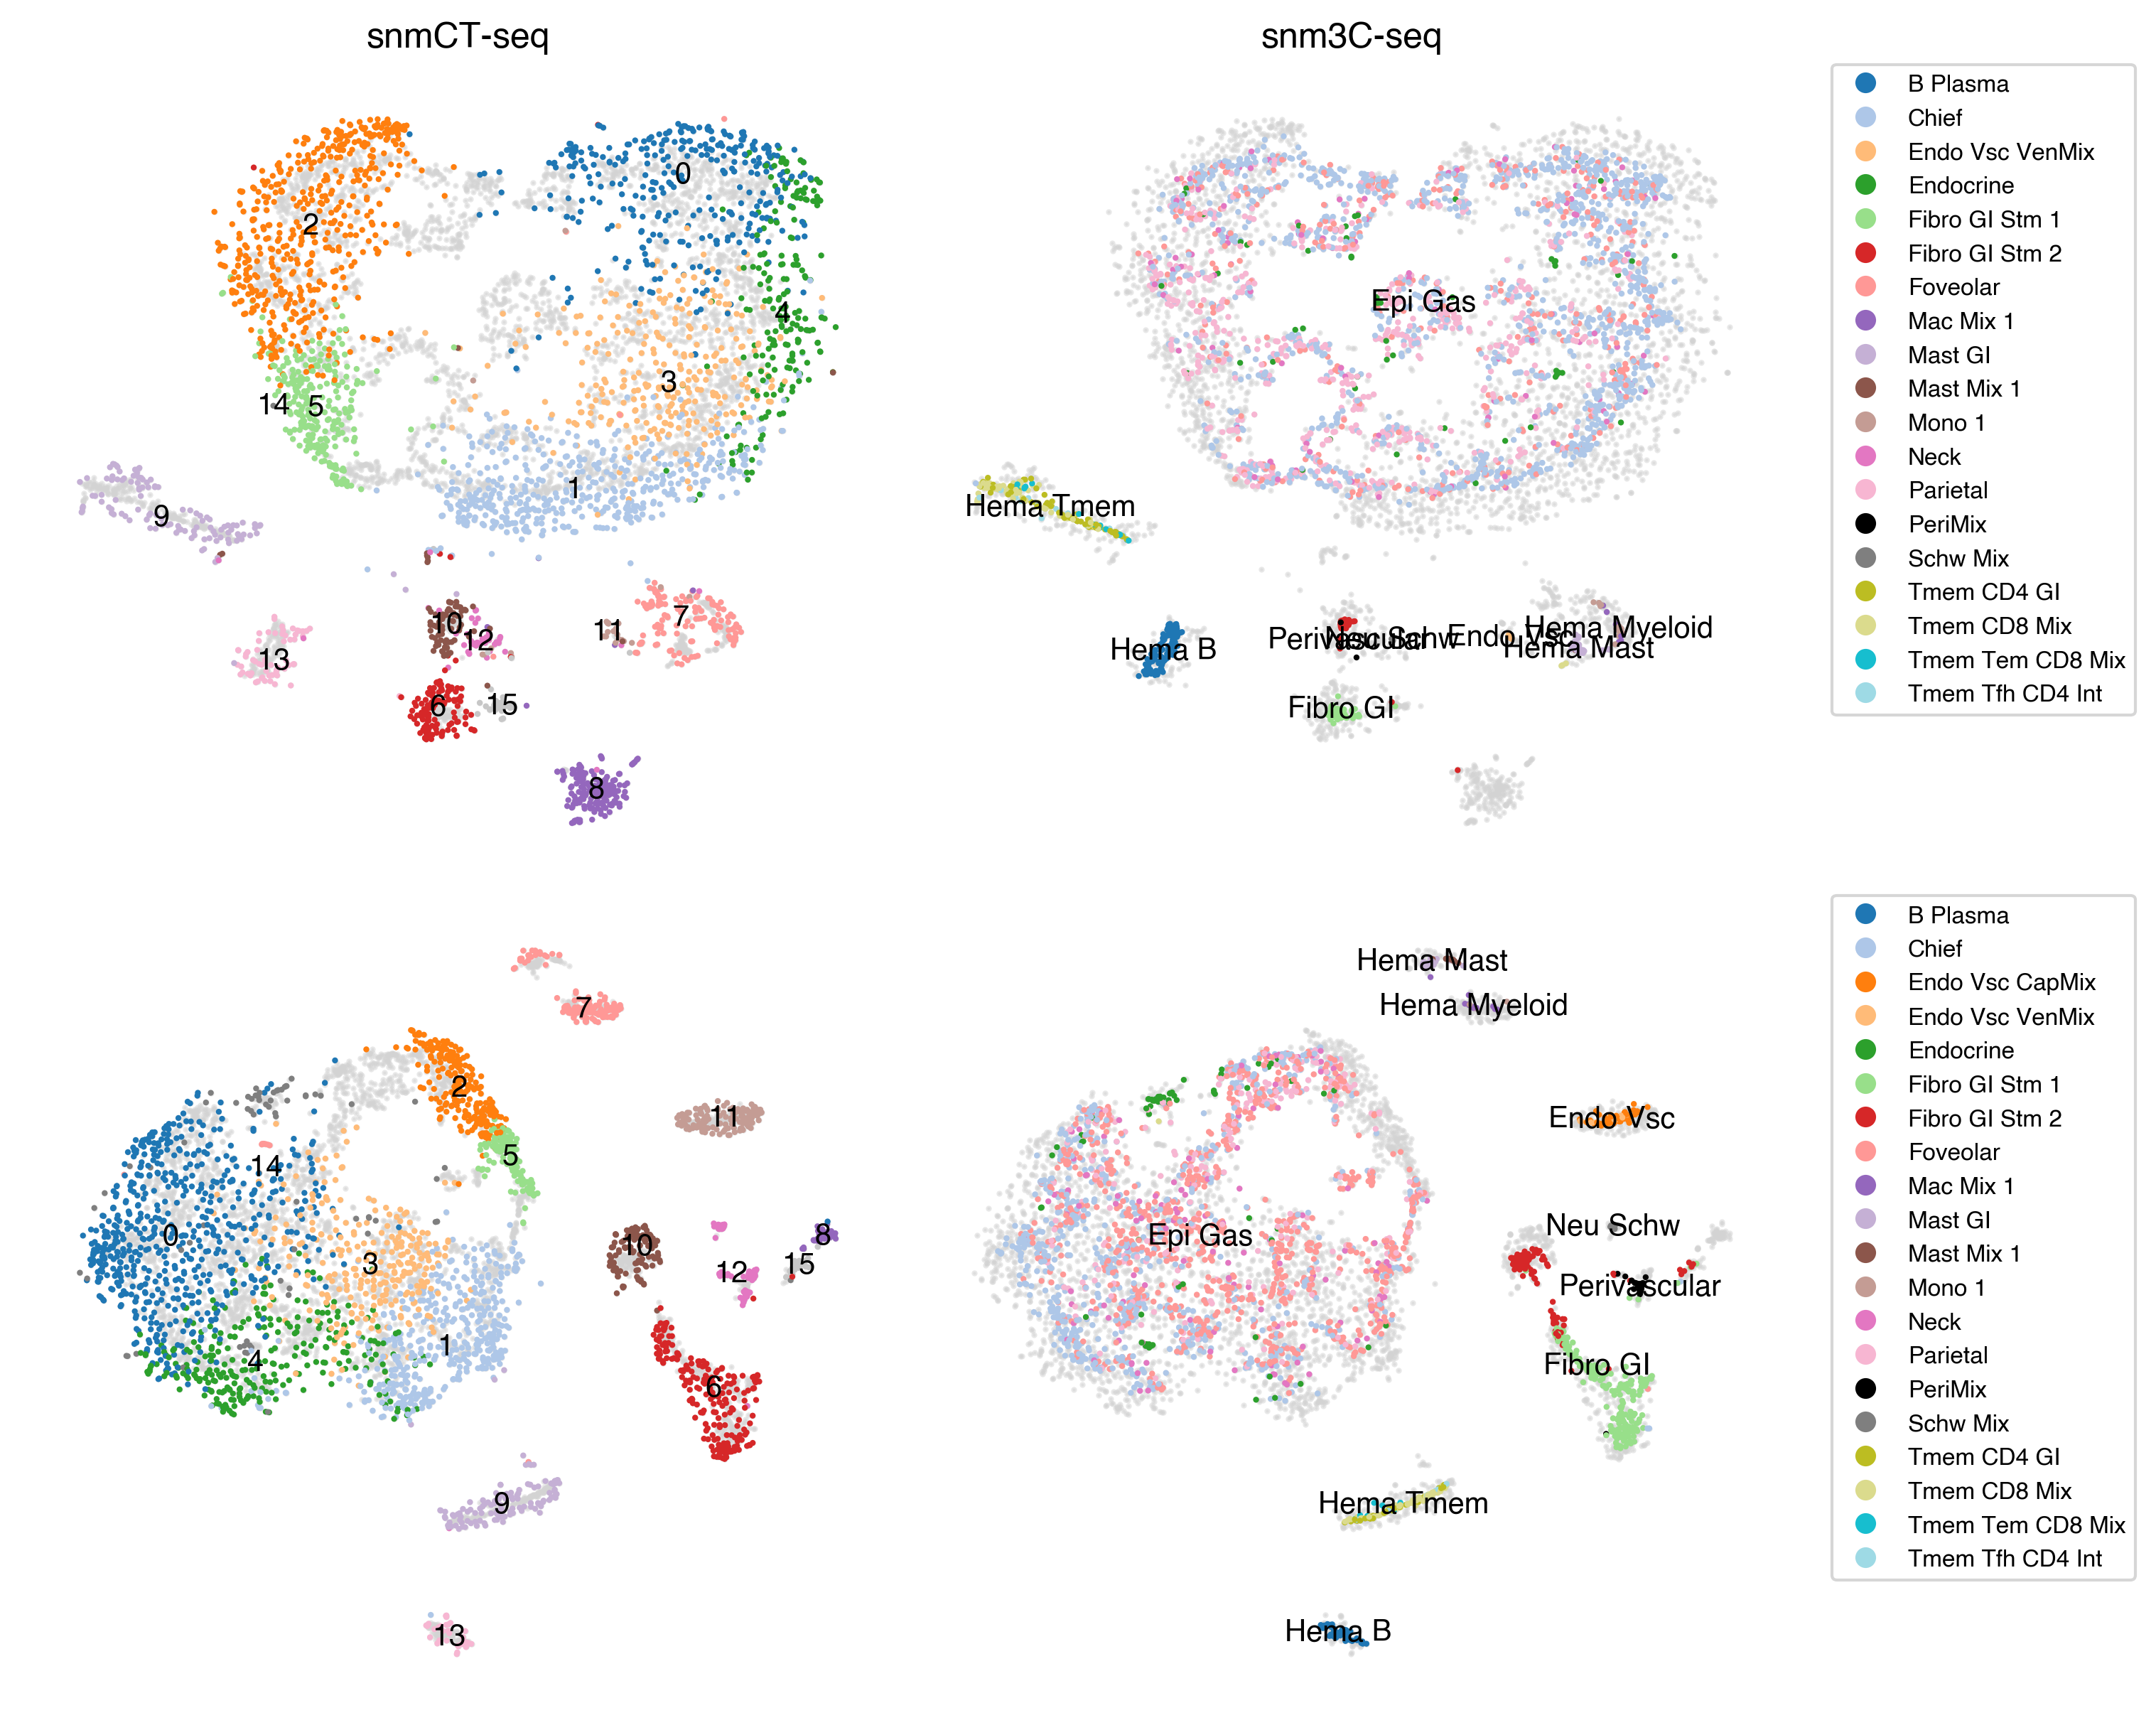

In [43]:
ds = 4
coord_base = 'tsne'

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300, constrained_layout=True)
for i,donor in enumerate(adata1.obs['Donor'].unique()):
    adata_merge = anndata.read_h5ad(f'{outdir}ST_mCT_m3C_{donor}_merged.h5ad')
    # adata_merge.obsm[f'X_{coord_base}'] = adata_merge.obsm[f'5kCG_u{npc}_seuratcc{npc}_tsne'].copy()
    dump_embedding(adata_merge, coord_base)
    tmp = adata_merge.obs.loc[adata_merge.obs['study']=='mCT'].copy()
    ax = axes[i,0]
    ax.scatter(adata_merge.obsm[f'X_{coord_base}'][:,0], adata_merge.obsm[f'X_{coord_base}'][:,1], s=1, c='lightgrey', alpha=0.5, rasterized=True)
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=f'5kCG_u17hm_leiden',
                            # text_anno=f'5kCG_u17hm_leiden',
                            labelsize=8,
                            s=ds,
                            palette=leiden_palette,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1},
                            # show_legend=True,
                            axis_format='empty',
                            )
    for yy,(x,y) in tmp.groupby('5kCG_u17hm_leiden')[[f'{coord_base}_0', f'{coord_base}_1']].median().iterrows():
        ax.text(x, y, yy, ha='center', va='center')

    tmp = adata_merge.obs.loc[adata_merge.obs['study']=='m3C'].copy()
    ax = axes[i,1]
    ax.scatter(adata_merge.obsm[f'X_{coord_base}'][:,0], adata_merge.obsm[f'X_{coord_base}'][:,1], s=1, c='lightgrey', alpha=0.5, rasterized=True)
    tmp = tmp.loc[tmp['L2_annot'].isin(selct)].copy()
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=f'L2_annot',
                            # text_anno=f'L2_annot',
                            labelsize=8,
                            s=ds,
                            palette=l2_palette,
                            scatter_kws={'rasterized':True},
                            legend_kws={'ncol':1},
                            show_legend=True,
                            axis_format='empty',
                            )
    for yy,(x,y) in tmp.groupby('L1_annot')[[f'{coord_base}_0', f'{coord_base}_1']].median().iterrows():
        ax.text(x, y, yy, ha='center', va='center')

for i,mode in enumerate(['snmCT-seq', 'snm3C-seq']):
    axes[0,i].set_title(mode)

fig.savefig(f'{outdir}ST_mCT_m3C_integration_seurat.pdf', transparent=True)
